# Lab 4: PCA

## Decision and Machine Learning, Centrale Lille

In this lab, we study the most fundamental dimensionality reduction method: PCA. More precisely, we apply it to the *Olivetti* dataset, which contains images of faces.

**Report by Ugo Roccamatisi.**


In [1]:
# Import usual libraries
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# The Olivetti cache is included in sklearn_data/; if it is missing, sklearn downloads the data on first run.
from sklearn.datasets import fetch_olivetti_faces
data=fetch_olivetti_faces(data_home='./sklearn_data',shuffle=False)

**Q1.** What is this dataset about ? How many examples do we have ? How many features ?

Display the first 50 images from the dataset. Comment.

Images, pixels: (400, 4096) people: 40 image shape: (64, 64)


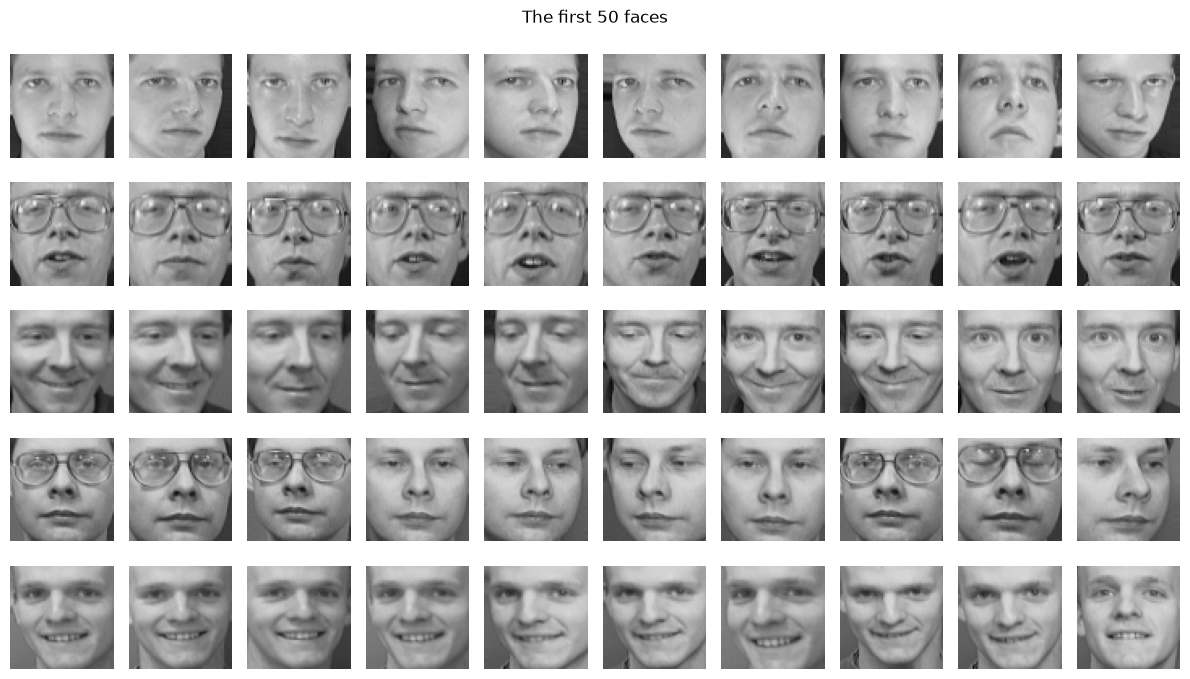

In [3]:
X=data.data;y=data.target
print('Images, pixels:',X.shape,'people:',len(np.unique(y)),'image shape:',data.images.shape[1:])
fig,axes=plt.subplots(5,10,figsize=(12,7))
for i,ax in enumerate(axes.flat):ax.imshow(data.images[i],cmap='gray',vmin=0,vmax=1);ax.axis('off')
fig.suptitle('The first 50 faces');fig.tight_layout();plt.show()

**Answer.** The dataset has 400 portraits (40 people × 10 photos), each a 64 × 64 image, i.e. 4,096 features. The first fifty show changes in lighting, expression and pose; the examples are grouped by person.

**Q2**. Now apply PCA to the dataset, using scikit-learn (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)).

Plot the cumulative explained variance. How many components do we need to explain 95% of the variance ?

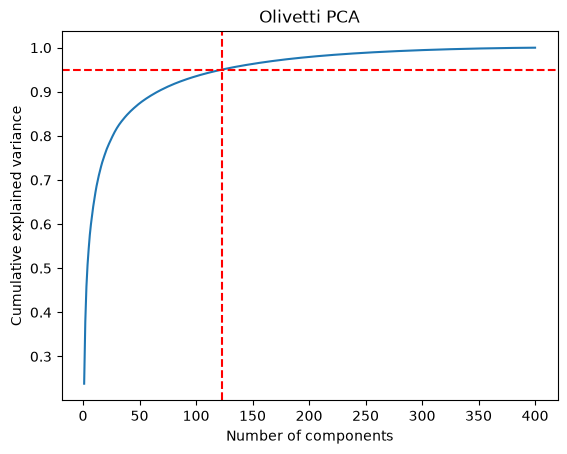

Components for ≥95%: 123 ; variance reached: 0.9504


In [4]:
from sklearn.decomposition import PCA
# PCA on centered data; n_components=None keeps all available components.
pca=PCA(svd_solver='full').fit(X)
cum=np.cumsum(pca.explained_variance_ratio_)
n95=int(np.searchsorted(cum,.95)+1)
fig,ax=plt.subplots();ax.plot(np.arange(1,len(cum)+1),cum);ax.axhline(.95,color='r',ls='--');ax.axvline(n95,color='r',ls='--')
ax.set(xlabel='Number of components',ylabel='Cumulative explained variance',title='Olivetti PCA');plt.show()
print('Components for ≥95%:',n95,'; variance reached:',round(cum[n95-1],4))

**Answer.** 123 components are needed to explain 95% of the variance (red vertical line), i.e. about 3% of the 4,096 original dimensions.

**Q3.** Retrieve the principal components. These are the so-called *eigenfaces*. Display the first 40, and comment : what do the main components seem to capture ? What about later components ?

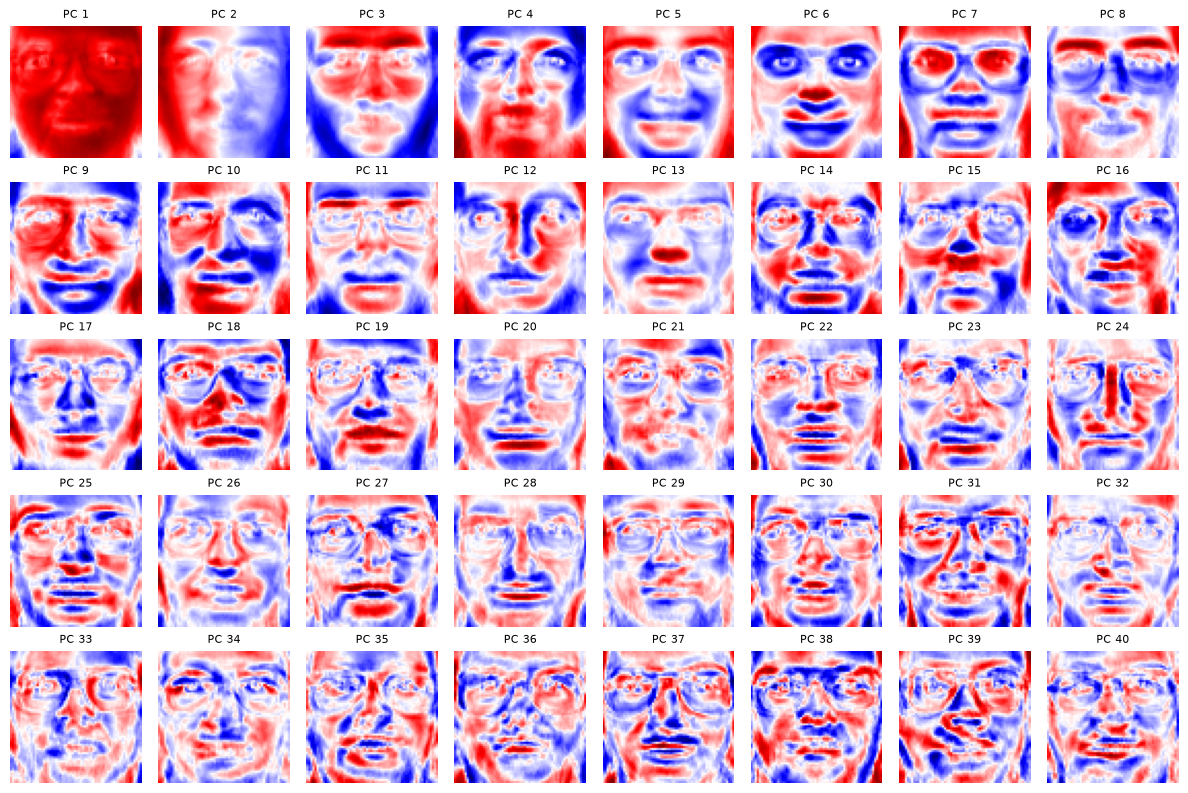

In [5]:
# Symmetric color scale for each eigenface, to show positive and negative signs.
fig,axes=plt.subplots(5,8,figsize=(12,8))
for i,ax in enumerate(axes.flat):
    face=pca.components_[i].reshape(64,64);v=np.max(np.abs(face))
    ax.imshow(face,cmap='seismic',vmin=-v,vmax=v);ax.set_title(f'PC {i+1}',fontsize=8);ax.axis('off')
fig.tight_layout();plt.show()

**Answer.** The first components capture global variations: lighting, position and shape of the face. Later components show localized details and weaker variations. The sign of a component is arbitrary.

**Q4.** The *Olivetti* dataset contains a target variable, which correspond to the ID of the person in the photo (there are 40 distinct persons).

Compare the cross-validated performance (e.g., 5-fold) of logistic regression on the original dataset vs. on the representation induced by PCA using the first 50 components. Be careful to *stratify* the test set. Comment. You may also take the execution time in consideration in your reply.

In [6]:
from sklearn.model_selection import StratifiedKFold,cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# Same 5 stratified folds for both models; the PCA is fitted INSIDE each fold.
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=0)
base=make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000,random_state=0))
reduced=make_pipeline(PCA(n_components=50,svd_solver='randomized',random_state=0),StandardScaler(),LogisticRegression(max_iter=2000,random_state=0))
for label,model in [('Original pixels',base),('PCA, 50 components',reduced)]:
    res=cross_validate(model,X,y,cv=cv,scoring='accuracy',n_jobs=1)
    print(f'{label}: accuracy={res["test_score"].mean():.3f} ± {res["test_score"].std():.3f} ; mean fit time={res["fit_time"].mean():.2f}s')

Original pixels: accuracy=0.975 ± 0.011 ; mean fit time=0.23s


PCA, 50 components: accuracy=0.963 ± 0.021 ; mean fit time=0.07s


**Answer.** Both scores come from the same stratified folds (8 portraits per person for training, 2 for validation). The PCA projection is refitted in each fold, which avoids data leakage. With 50 components (instead of 4,096 pixels), accuracy drops only slightly (96.3% vs 97.5%) while fitting is about 6 times faster.

**Q5**. To reconstruct a point back in its original representation, we can use the `.inverse_transform` method.

Since we are working with images, after reducing the dimensionality, we will obtain an imperfect reconstruction of the original image.

Set now the number of components of PCA to 300. Select an image from the dataset, and compare it to its reconstruction. You may assess the quality of the reconstruction with a metric of your choice.

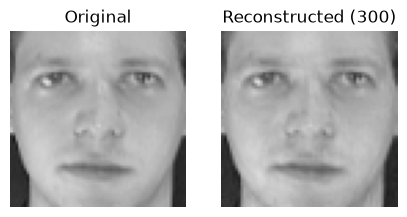

Pixel MSE (300): 0.00012695233


In [7]:
# 300 components; the full SVD avoids randomness in the reconstruction.
pca300=PCA(n_components=300,svd_solver='full').fit(X)
index=0;original=X[index];scores=pca300.transform(X[index:index+1])[0]
recon=pca300.inverse_transform(scores[None,:])[0]
fig,axes=plt.subplots(1,2,figsize=(5,3))
for ax,im,title in zip(axes,(original,recon),('Original','Reconstructed (300)')):ax.imshow(im.reshape(64,64),cmap='gray',vmin=0,vmax=1);ax.set_title(title);ax.axis('off')
plt.show()
print('Pixel MSE (300):',np.mean((original-recon)**2))

**Answer.** The mean per-pixel MSE quantifies the loss due to the projection on 300 components; the two images are visually almost identical.

**Q6.** For the same image, display with subplots how the reconstruction evolves while keeping only 10, 20, 30... Up to 300 components.

What is the minimal number of components for which you consider the reconstruction to be acceptable ?

Conclude about the usefulness of this method.

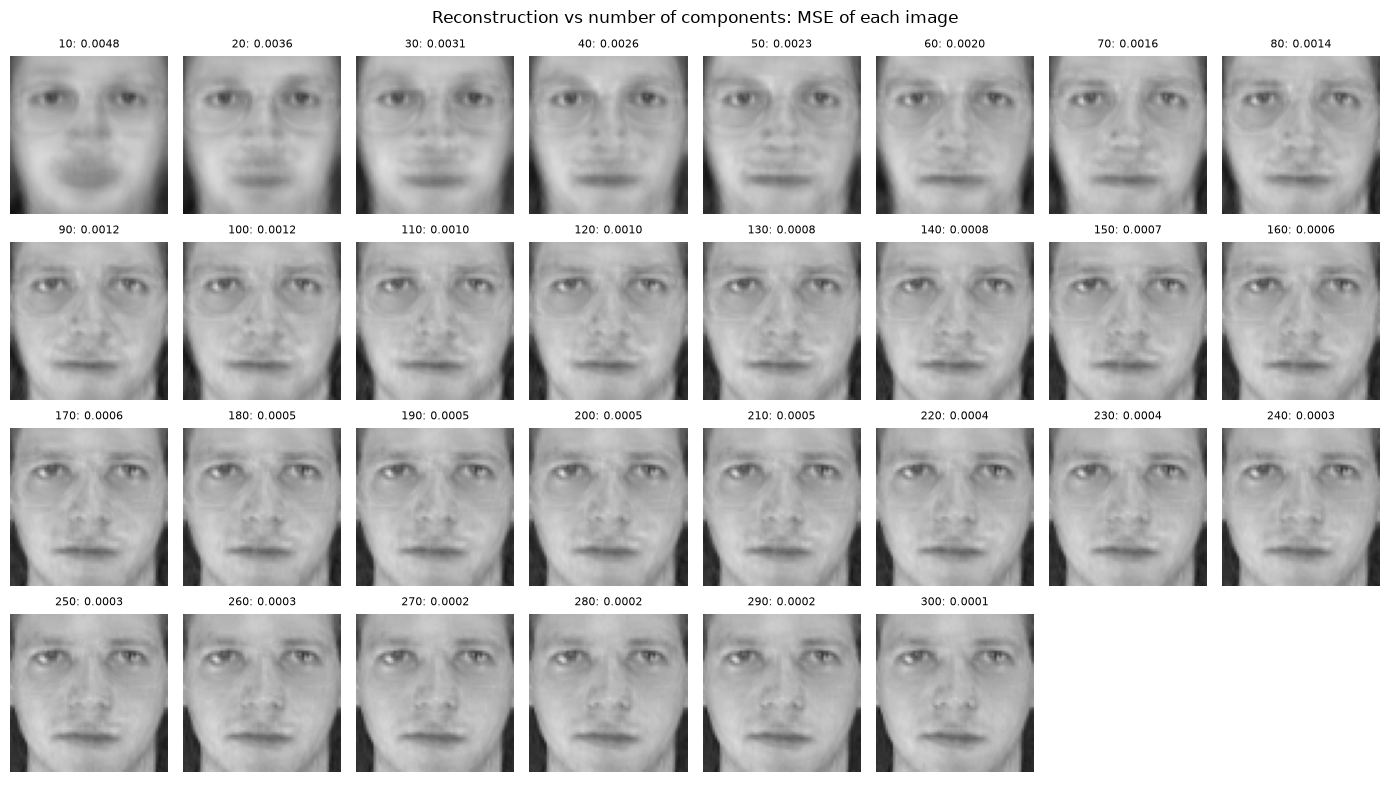

MSE at 10, 50, 100, 300: [(10, 0.0048), (50, 0.0023), (100, 0.00115), (300, 0.00013)]


In [8]:
# Truncated projection: mean + sum of the first k scores × components.
ks=list(range(10,301,10))
fig,axes=plt.subplots(4,8,figsize=(14,8))
for ax,k in zip(axes.flat,ks):
    im=pca300.mean_+scores[:k]@pca300.components_[:k]
    ax.imshow(im.reshape(64,64),cmap='gray',vmin=0,vmax=1);ax.set_title(f'{k}: {np.mean((original-im)**2):.4f}',fontsize=8);ax.axis('off')
for ax in list(axes.flat)[len(ks):]:ax.axis('off')
fig.suptitle('Reconstruction vs number of components: MSE of each image');fig.tight_layout();plt.show()
print('MSE at 10, 50, 100, 300:',[(k,round(float(np.mean((original-(pca300.mean_+scores[:k]@pca300.components_[:k]))**2)),5)) for k in (10,50,100,300)])

**Answer.** The "acceptable" threshold is visual and depends on the use case; for this portrait, about 100 components already give an easily recognizable face, while 300 keep finer details. The MSE values and the grid can be used to choose another threshold. PCA compresses the images, at the cost of some information loss and an imperfect reconstruction.